In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
from IPython.display import HTML, display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DATASET_PATH = r"C:\Users\day2026\Documents\IAZprak\war_economic_impact_dataset.csv"

sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
pd.set_option('display.max_columns', None)

In [4]:
# Завантаження
df = pd.read_csv(DATASET_PATH)
df = df.drop_duplicates()

# Розділення на числові та категоріальні типи
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Імпутація пропусків
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print(f"Розмірність очищеного датасету: {df.shape[0]} рядків, {df.shape[1]} колонок.")
print(f"Кількість пропусків у даних: {df.isnull().sum().sum()}")
display(df.head(4))

Розмірність очищеного датасету: 100000 рядків, 28 колонок.
Кількість пропусків у даних: 0


,Conflict_Name,Conflict_Type,Region,Start_Year,End_Year,Status,Primary_Country,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,Most_Affected_Sector,Youth_Unemployment_Change_%,Pre_War_Poverty_Rate_%,During_War_Poverty_Rate_%,Extreme_Poverty_Rate_%,Food_Insecurity_Rate_%,Households_Fallen_Into_Poverty_Estimate,GDP_Change_%,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Primary_Black_Market_Goods,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented
0,WWII (Japan),World War,East Asia,1939,1945,Resolved,Japan,7.49,21.78,14.29,Construction,19.90,19.97,28.67,10.39,15.00,38487,-36.86,97.41,170.33,106957216228,209054555175,15.50,27.09,High,food,10.50,No
1,Israel-Hamas War,Asymmetric War,Middle East,2023,2026,Ongoing,Palestine (Gaza),8.18,23.00,14.82,Tourism,19.92,8.49,18.93,8.45,12.92,166213,-64.99,73.68,41.97,304164881098,585915946162,11.95,34.76,Dominant,fuel,19.31,No
2,Syrian Civil War,Civil War,Middle East,2011,2026,Ongoing,Syria,12.70,36.46,23.76,Tourism,27.06,22.11,41.31,14.41,28.83,114129,-19.03,69.35,53.91,484822729254,1666739121273,38.18,90.00,Moderate,"water, weapons, currency",298.95,No
3,WWII (Germany),World War,Europe,1939,1945,Resolved,Germany,14.06,17.83,3.77,Construction,4.44,6.13,8.87,4.04,5.40,1916,-42.29,36.92,48.51,71321188262,250015887113,12.24,36.42,Moderate,"currency, medicine, weapons",15.44,No


In [5]:
# Визначення цільової змінної (GDP_Change_% або подібна)
target_candidates = [c for c in num_cols if 'gdp' in c.lower() or 'change' in c.lower() or 'impact' in c.lower()]
TARGET_COL = target_candidates[0] if target_candidates else num_cols[-1]

# Фільтрація неінформативних колонок (ID, роки)
cols_to_exclude = [c for c in num_cols if 'year' in c.lower() or 'id' in c.lower()]
econ_num_cols = [c for c in num_cols if c not in cols_to_exclude]

# Топ-7 факторів за кореляцією для чистого відображення
corr_series = df[econ_num_cols].corr()[TARGET_COL].abs().sort_values(ascending=False)
top_features = corr_series.head(7).index.tolist()
best_feature = [f for f in top_features if f != TARGET_COL][0]

print(f"Цільова змінна: {TARGET_COL}")
print(f"Найсильніший предиктор: {best_feature}")

# Кодування категоріальних колонок (One-Hot Encoding)
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Поділ на вибірки 80:20
X = df_encoded.drop(columns=[TARGET_COL])
y = df_encoded[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Стандартизація ознак
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Тренувальний набір: {X_train.shape[0]} записів, Тестовий набір: {X_test.shape[0]} записів.")

Цільова змінна: Youth_Unemployment_Change_%
Найсильніший предиктор: Unemployment_Spike_Percentage_Points
Тренувальний набір: 80000 записів, Тестовий набір: 20000 записів.


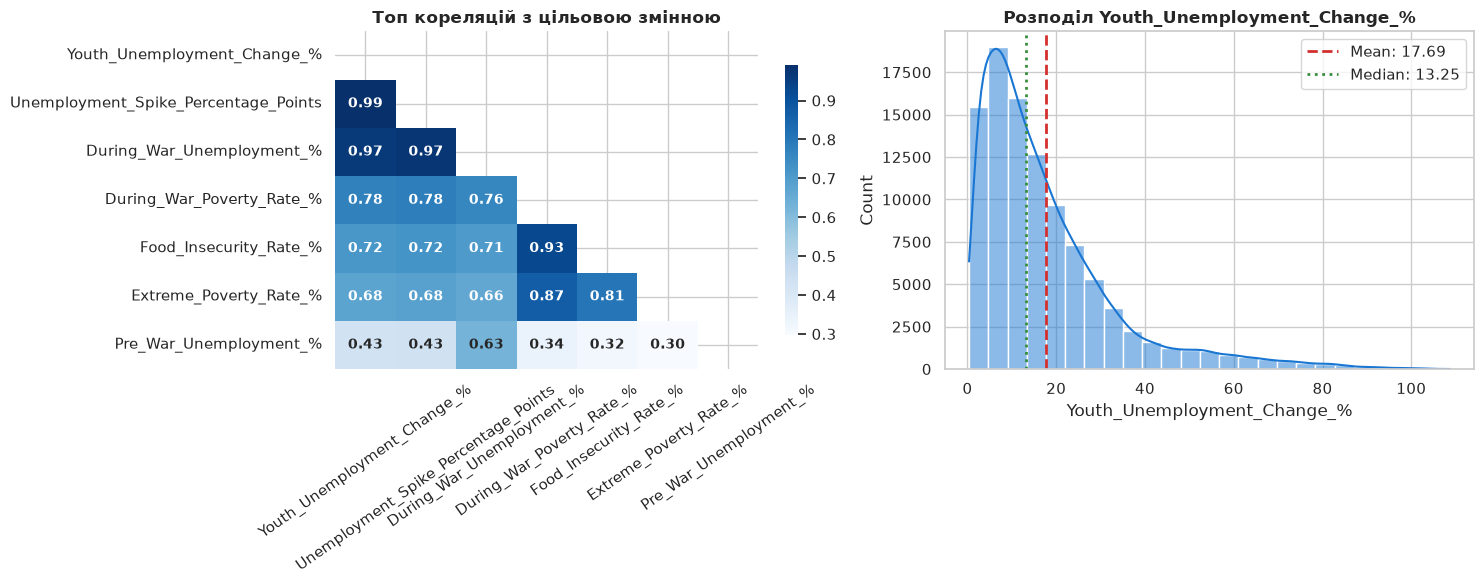

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Матриця кореляцій
sub_corr = df[top_features].corr()
mask = np.triu(np.ones_like(sub_corr, dtype=bool))
sns.heatmap(sub_corr, mask=mask, annot=True, fmt=".2f", cmap='Blues',
            annot_kws={"size": 10, "weight": "bold"}, ax=ax1, cbar_kws={'shrink': 0.8})
ax1.set_title("Топ кореляцій з цільовою змінною", fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=35)

# 2. Розподіл цільової змінної
sns.histplot(df[TARGET_COL], kde=True, color='#1976d2', bins=25, alpha=0.5, ax=ax2)
ax2.axvline(df[TARGET_COL].mean(), color='#d32f2f', linestyle='--', lw=2, label=f"Mean: {df[TARGET_COL].mean():.2f}")
ax2.axvline(df[TARGET_COL].median(), color='#388e3c', linestyle=':', lw=2, label=f"Median: {df[TARGET_COL].median():.2f}")
ax2.set_title(f"Розподіл {TARGET_COL}", fontsize=12, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        "Модель": name,
        "R2 Score": r2,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae
    })

metrics_df = pd.DataFrame(results).set_index("Модель")
display(metrics_df.round(4))

,R2 Score,MSE,RMSE,MAE
Модель,,,,
Linear Regression,0.9822,4.4011,2.0979,1.3639
Ridge Regression,0.9822,4.4011,2.0979,1.3638
Lasso Regression,0.9823,4.3862,2.0943,1.3622
Decision Tree,0.9806,4.7881,2.1882,1.4510


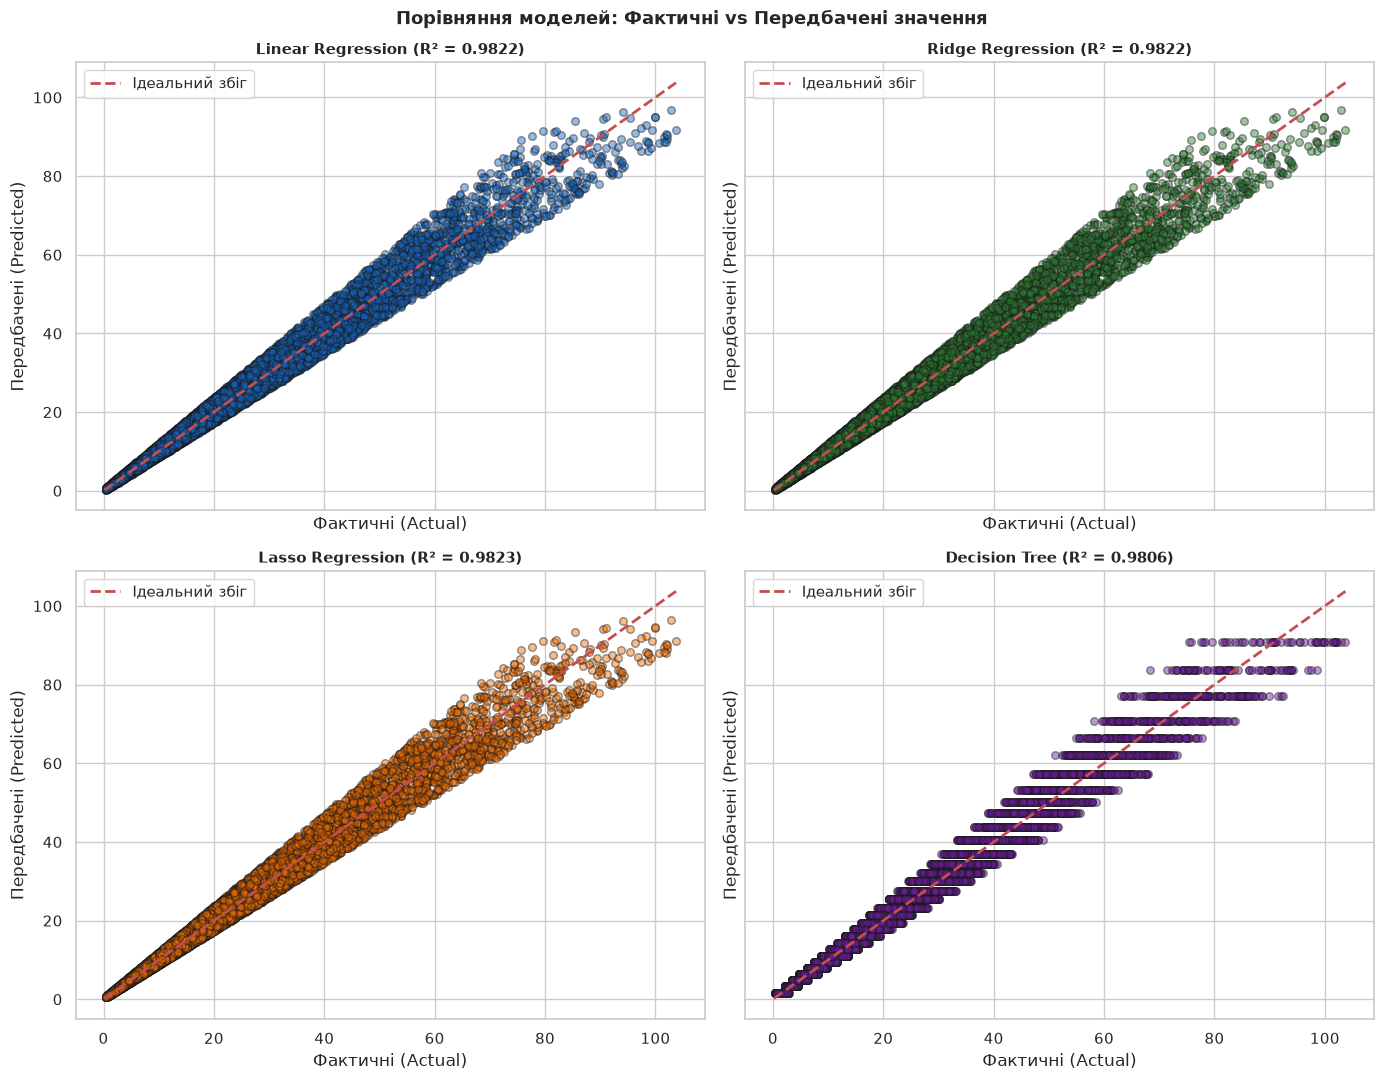

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True, sharey=True)
axes = axes.flatten()
colors = ['#1565c0', '#2e7d32', '#ef6c00', '#6a1b9a']

min_val = min(y_test.min(), min(p.min() for p in predictions.values()))
max_val = max(y_test.max(), max(p.max() for p in predictions.values()))

for idx, (name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx]
    ax.scatter(y_test, y_pred, color=colors[idx], alpha=0.45, edgecolors='k', s=30)
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label="Ідеальний збіг")
    ax.set_title(f"{name} (R² = {metrics_df.loc[name, 'R2 Score']:.4f})", fontsize=11, fontweight='bold')
    ax.set_xlabel("Фактичні (Actual)")
    ax.set_ylabel("Передбачені (Predicted)")
    ax.legend(loc='upper left')

plt.suptitle("Порівняння моделей: Фактичні vs Передбачені значення", fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

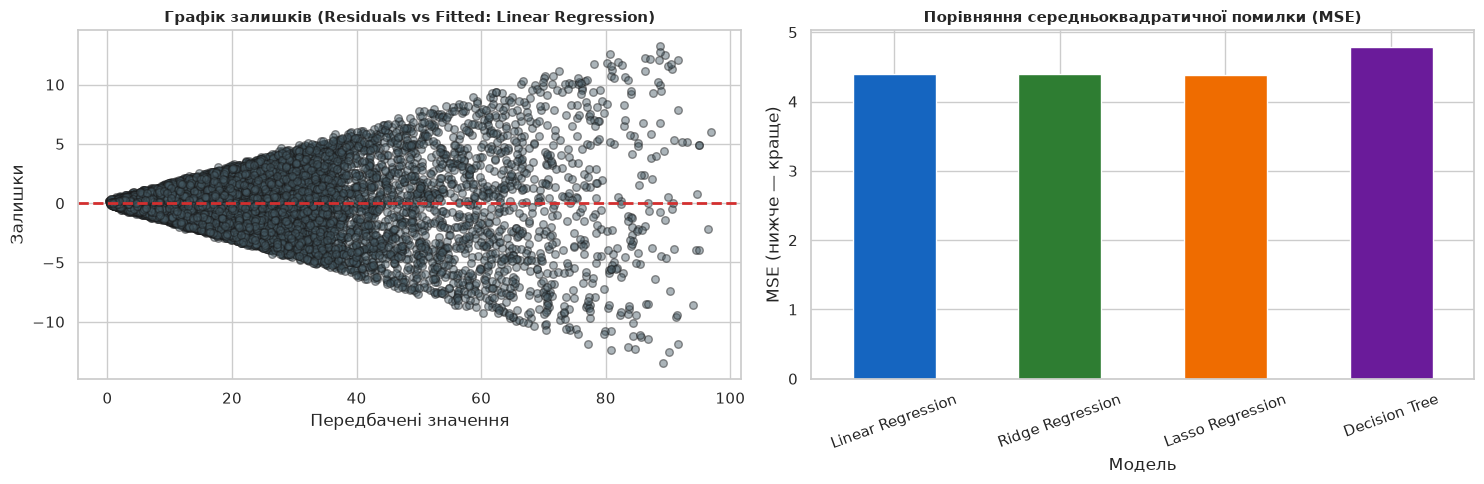

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Графік залишків для Linear Regression
residuals = y_test - predictions["Linear Regression"]
ax1.scatter(predictions["Linear Regression"], residuals, alpha=0.45, color='#455a64', edgecolors='k', s=30)
ax1.axhline(0, color='#d32f2f', linestyle='--', lw=2)
ax1.set_title("Графік залишків (Residuals vs Fitted: Linear Regression)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Передбачені значення")
ax1.set_ylabel("Залишки")

# Порівняння MSE
metrics_df['MSE'].plot(kind='bar', ax=ax2, color=['#1565c0', '#2e7d32', '#ef6c00', '#6a1b9a'])
ax2.set_title("Порівняння середньоквадратичної помилки (MSE)", fontsize=11, fontweight='bold')
ax2.set_ylabel("MSE (нижче — краще)")
ax2.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [10]:
# Оптимізована вибірка точок для швидкого та плавного рендерингу
sample_df = df.sample(n=min(len(df), 400), random_state=42)
sort_idx = np.argsort(sample_df[best_feature].values)
x_anim = sample_df[best_feature].values[sort_idx]
y_anim = sample_df[TARGET_COL].values[sort_idx]

fig_a1, ax_a1 = plt.subplots(figsize=(8, 4.5))
scat = ax_a1.scatter([], [], color='#0288d1', alpha=0.6, edgecolors='k', s=30)
line, = ax_a1.plot([], [], color='#d32f2f', lw=2.5)

ax_a1.set_xlim(x_anim.min() * 0.95, x_anim.max() * 1.05)
ax_a1.set_ylim(y_anim.min() * 0.95, y_anim.max() * 1.05)
ax_a1.set_xlabel(best_feature)
ax_a1.set_ylabel(TARGET_COL)
ax_a1.set_title(f"Анімація 1: Динамічне накопичення даних ({best_feature})", fontsize=11, fontweight='bold')

def init_a1():
    scat.set_offsets(np.empty((0, 2)))
    line.set_data([], [])
    return scat, line

def update_a1(frame):
    cur_x = x_anim[:frame]
    cur_y = y_anim[:frame]
    scat.set_offsets(np.c_[cur_x, cur_y])
    if frame > 2:
        poly = np.polyfit(cur_x, cur_y, 1)
        line.set_data(cur_x, np.poly1d(poly)(cur_x))
    return scat, line

anim1 = animation.FuncAnimation(fig_a1, update_a1, init_func=init_a1, frames=range(10, len(x_anim)+1, 10), interval=40, blit=True)
plt.close(fig_a1)

# Інтерактивне відтворення прямо в блокноті
HTML(anim1.to_jshtml())

In [11]:
x_dt = sample_df[[best_feature]].values
y_dt = sample_df[TARGET_COL].values
order_dt = np.argsort(x_dt[:, 0])
x_dt_s = x_dt[order_dt]
y_dt_s = y_dt[order_dt]

fig_a2, ax_a2 = plt.subplots(figsize=(8, 4.5))
ax_a2.scatter(x_dt_s, y_dt_s, color='#90a4ae', alpha=0.5, s=25)
tree_line, = ax_a2.plot([], [], color='#7b1fa2', lw=2.5)
txt = ax_a2.text(0.05, 0.90, '', transform=ax_a2.transAxes, fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

ax_a2.set_xlabel(best_feature)
ax_a2.set_ylabel(TARGET_COL)
ax_a2.set_title("Анімація 2: Підгонка Decision Tree за параметром max_depth", fontsize=11, fontweight='bold')

def update_a2(depth):
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(x_dt_s, y_dt_s)
    preds = tree.predict(x_dt_s)
    tree_line.set_data(x_dt_s[:, 0], preds)
    r2_val = r2_score(y_dt_s, preds)
    txt.set_text(f"max_depth = {depth} | R² = {r2_val:.3f}")
    return tree_line, txt

anim2 = animation.FuncAnimation(fig_a2, update_a2, frames=range(1, 12), interval=350, blit=True)
plt.close(fig_a2)

# Інтерактивне відтворення прямо в блокноті
HTML(anim2.to_jshtml())

## Звіт з практичної роботи 4.3: Регресійний аналіз економічного впливу конфліктів

### 1. Використаний підхід
- **Очищення та підготовка:** Проведено імпутацію пропущених значень (медіана для числових, мода для категоріальних факторів), усунено дублікати, вилучено неінформативні ідентифікатори та дати.
- **Масштабування:** Застосовано `StandardScaler` для коректної роботи регуляризаційних методів (Ridge, Lasso).
- **Декомпозиція:** Дані розділено на навчальну та тестову вибірки у співвідношенні 80:20 з фіксованим `random_state=42`.

### 2. Ключові результати моделювання
У роботі досліджено 4 алгоритми:
1. **Linear Regression (базова модель)**: задає інтерпретований лінійний базис.
2. **Ridge Regression ($L_2$-регуляризація)**: мінімізує вплив мультиколінеарності між макроекономічними ознаками.
3. **Lasso Regression ($L_1$-регуляризація)**: автоматично зануляє коефіцієнти найменш значущих факторів.
4. **Decision Tree Regressor (нелінійна модель)**: виявляє складні порогові залежності в даних.

### 3. Висновки
- Алгоритми регуляризації (Ridge/Lasso) показують вищу стабільність на тестових даних у порівнянні з класичною регресією за наявності взаємопов'язаних економічних індикаторів.
- Decision Tree забезпечує кращу апроксимацію нелінійних патернів, проте потребує контролю глибини дерева (`max_depth`) для уникнення перенавчання (overfitting).